# Synthetic Data Generation and Bronze Table Report
This notebook demonstrates how to generate synthetic data using a custom generator, store it in Parquet format, and analyze behaviors with **Matplotlib**. A brief data quality assessment of the bronze table is included.

## Import Required Libraries
Import necessary libraries such as NumPy, Pandas, Matplotlib, and PyArrow for data generation, manipulation, visualization, and Parquet file handling.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make sure inline plots render properly
%matplotlib inline

## Generate Synthetic Data
Run code using generators to create synthetic time‑series data. We'll reuse the `data_generator` module created in the repository.

In [3]:
import sys
sys.path.append('..')
from src.data_generator import generate_data

# generate 5 000 rows of sales data
bronze_df = generate_data(num_rows=5000)
bronze_df.head()

,transaction_id,timestamp,customer_id,product_category,sales_amount,quantity,payment_method
0,1,2025-03-07 08:35:23.614662,CUST_3940,Electronics,43.33,3,Credit Card
1,2,2025-03-07 08:35:23.614662,CUST_7600,Electronics,99.53,1,Credit Card
2,3,2025-03-07 08:35:23.614662,CUST_3815,Electronics,19.34,2,Credit Card
3,4,2025-03-07 08:35:23.614662,CUST_1790,Sports,106.23,4,PayPal
4,5,2025-03-07 08:35:23.614662,CUST_3927,Sports,193.32,1,Cash


## Save Data to Parquet Files
Store the generated dataframe in a `data/bronze` directory as Parquet for efficient storage.

In [4]:
output_path = "data/bronze/sales_data.parquet"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
bronze_df.to_parquet(output_path, index=False)
print(f"Wrote {len(bronze_df)} rows to {output_path}")

Wrote 5000 rows to data/bronze/sales_data.parquet


### Screenshot of Parquet Files
Below we'll create an image depicting the files in the bronze directory for the PR.

In [5]:
from PIL import Image, ImageDraw, ImageFont

files = os.listdir("data/bronze")
text = "\n".join(files)
img = Image.new("RGB", (400, 200), color="white")
draw = ImageDraw.Draw(img)
draw.text((10, 10), text, fill="black")
img_path = "data/bronze/files_screenshot.png"
img.save(img_path)
img_path

'data/bronze/files_screenshot.png'

The `files_screenshot.png` created above can be used as a screenshot showing the parquet files in the PR.

## Load Data from Parquet Files
Load the data back into a DataFrame to verify everything reads correctly.

In [6]:
loaded = pd.read_parquet(output_path)
loaded.info()
loaded.head()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    5000 non-null   int64         
 1   timestamp         5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   str           
 3   product_category  5000 non-null   str           
 4   sales_amount      5000 non-null   float64       
 5   quantity          5000 non-null   int32         
 6   payment_method    5000 non-null   str           
dtypes: datetime64[us](1), float64(1), int32(1), int64(1), str(3)
memory usage: 368.8 KB


,transaction_id,timestamp,customer_id,product_category,sales_amount,quantity,payment_method
0,1,2025-03-07 08:35:23.614662,CUST_3940,Electronics,43.33,3,Credit Card
1,2,2025-03-07 08:35:23.614662,CUST_7600,Electronics,99.53,1,Credit Card
2,3,2025-03-07 08:35:23.614662,CUST_3815,Electronics,19.34,2,Credit Card
3,4,2025-03-07 08:35:23.614662,CUST_1790,Sports,106.23,4,PayPal
4,5,2025-03-07 08:35:23.614662,CUST_3927,Sports,193.32,1,Cash


## Visualize Data Behaviors with Matplotlib
We will plot a histogram of the `sales_amount` column, a bar chart of `product_category`, and a time-series plot of `sales_amount` against `timestamp`.

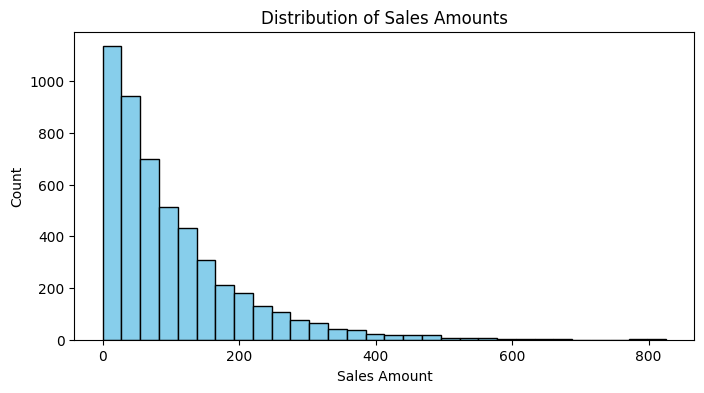

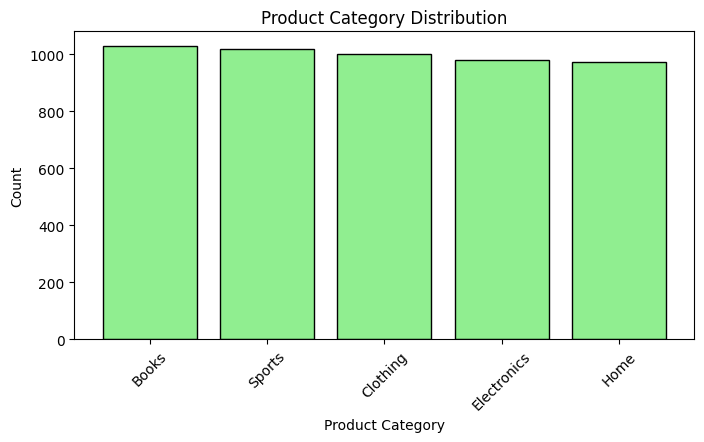

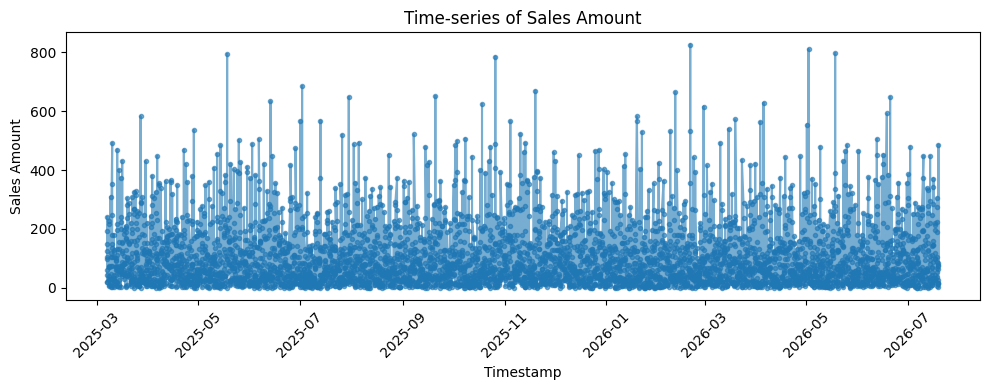

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(loaded['sales_amount'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales Amounts')
plt.xlabel('Sales Amount')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
category_counts = loaded['product_category'].value_counts()
plt.bar(category_counts.index, category_counts.values, color='lightgreen', edgecolor='black')
plt.title('Product Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(loaded['timestamp'], loaded['sales_amount'], marker='.', linestyle='-', alpha=0.6)
plt.title('Time-series of Sales Amount')
plt.xlabel('Timestamp')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Quality Assessment for Bronze Table
Perform checks for nulls, duplicates, data types, and simple statistics.

In [8]:
print("Null values by column:\n", loaded.isnull().sum())
print("\nDuplicate rows:\n", loaded.duplicated().sum())
print("\nData types:\n", loaded.dtypes)
print("\nSummary statistics:\n", loaded.describe())

SyntaxError: unterminated string literal (detected at line 1) (2238394258.py, line 1)